Предмет "Искусственный интеллект"

Лабораторная работа №5

Грибушенков Михаил, группа РФЗ-2-2022

Понижение размерности винного датасета

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# defines
filename = "winequality-white[1].csv"

In [2]:
db = pd.read_csv (filename, sep=";") # Загрузка базы данных из файла
db.info() # Статистика по БД
db.head(10)

# Нормализация датасета
for column in db.columns:
    db[column] = db[column] / db[column].abs().max()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


Нормализованное.

<Axes: >

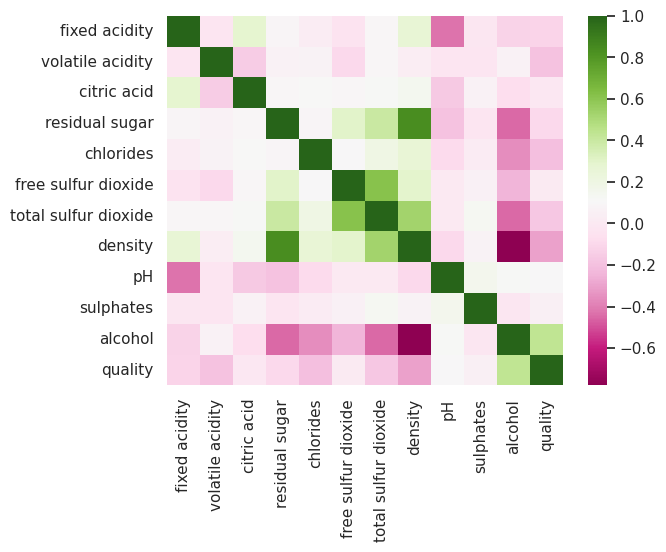

In [ ]:
sns.heatmap(db.corr(numeric_only = True), cmap="PiYG")

Тут много фич с малой корреляцией. Понижение размерности может помочь в кластеризации...

In [5]:
from sklearn.cluster import KMeans

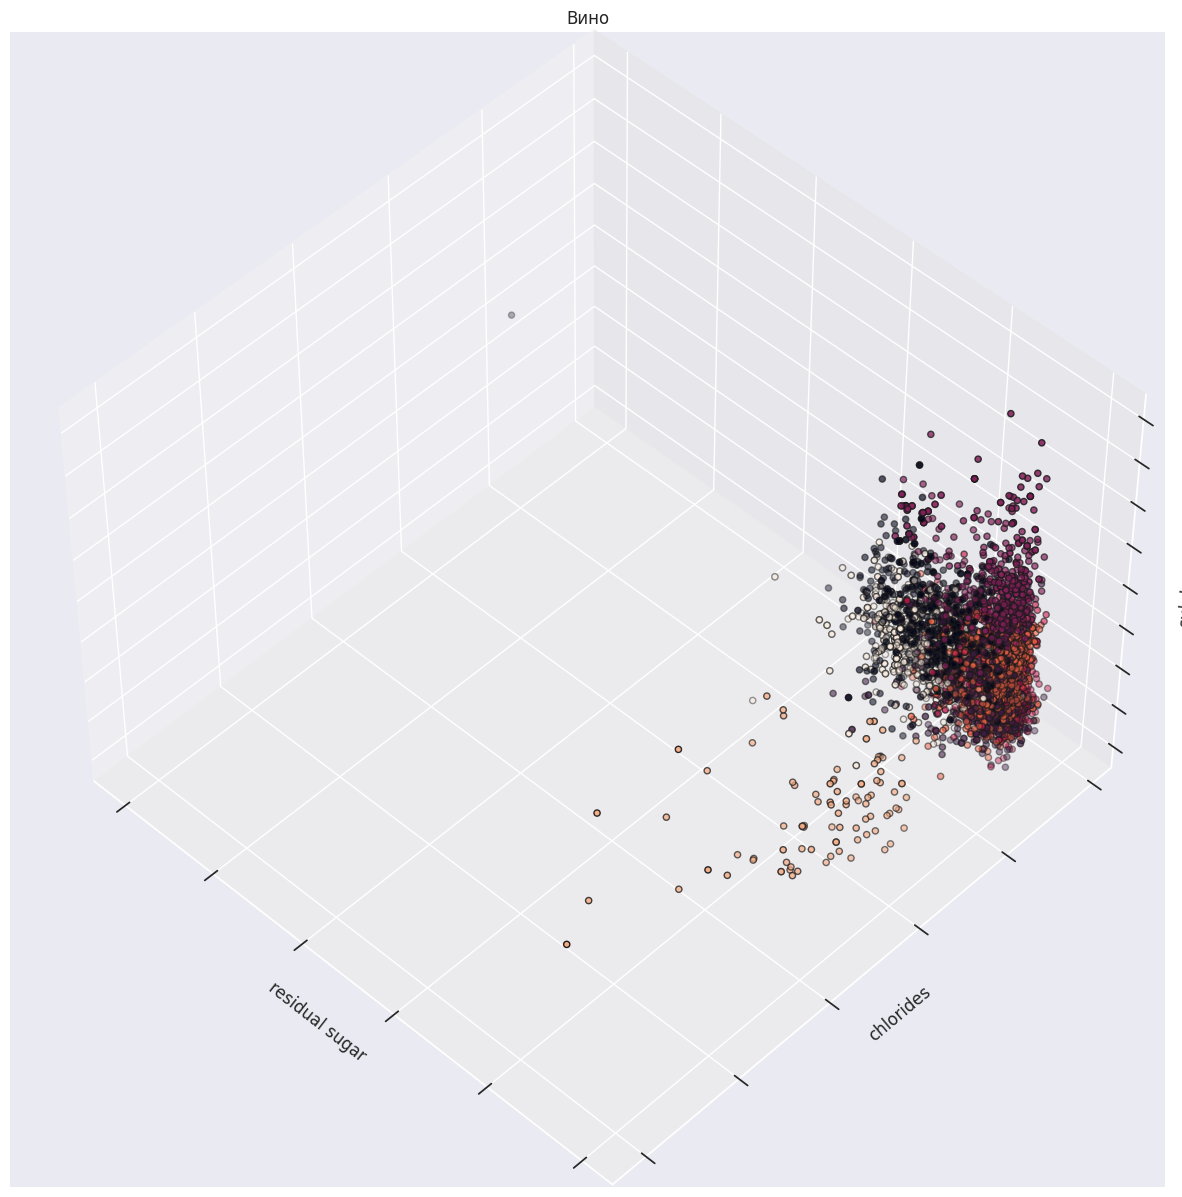

In [ ]:
# Кластеризация без понижения размерности
est = KMeans(n_clusters=7, max_iter=10, n_init=10)
est.fit(db)

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db["residual sugar"], db["chlorides"], db["sulphates"],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("residual sugar")
ax.set_ylabel ("chlorides")
ax.set_zlabel ("sulphates")
ax.set_title ("Вино")

plt.show()

# Вот так как-то. Семь групп вин, из них три визуально выделяются.

In [ ]:
from sklearn.decomposition import PCA

# Понижение размерности методом главных компонентов (Principal Component Analysis, PCA)
pca = PCA(n_components=3)
db_pcaed = pca.fit(db).transform(db)
db_pcaed

array([[ 0.1781545 , -0.01331181, -0.11301237],
       [-0.01801928, -0.01428678,  0.03396352],
       [-0.03745619, -0.05393942, -0.02513549],
       ...,
       [-0.04748479, -0.04100673, -0.00497247],
       [-0.24367171, -0.04407229, -0.03085158],
       [-0.18055855, -0.11981056, -0.07310737]])

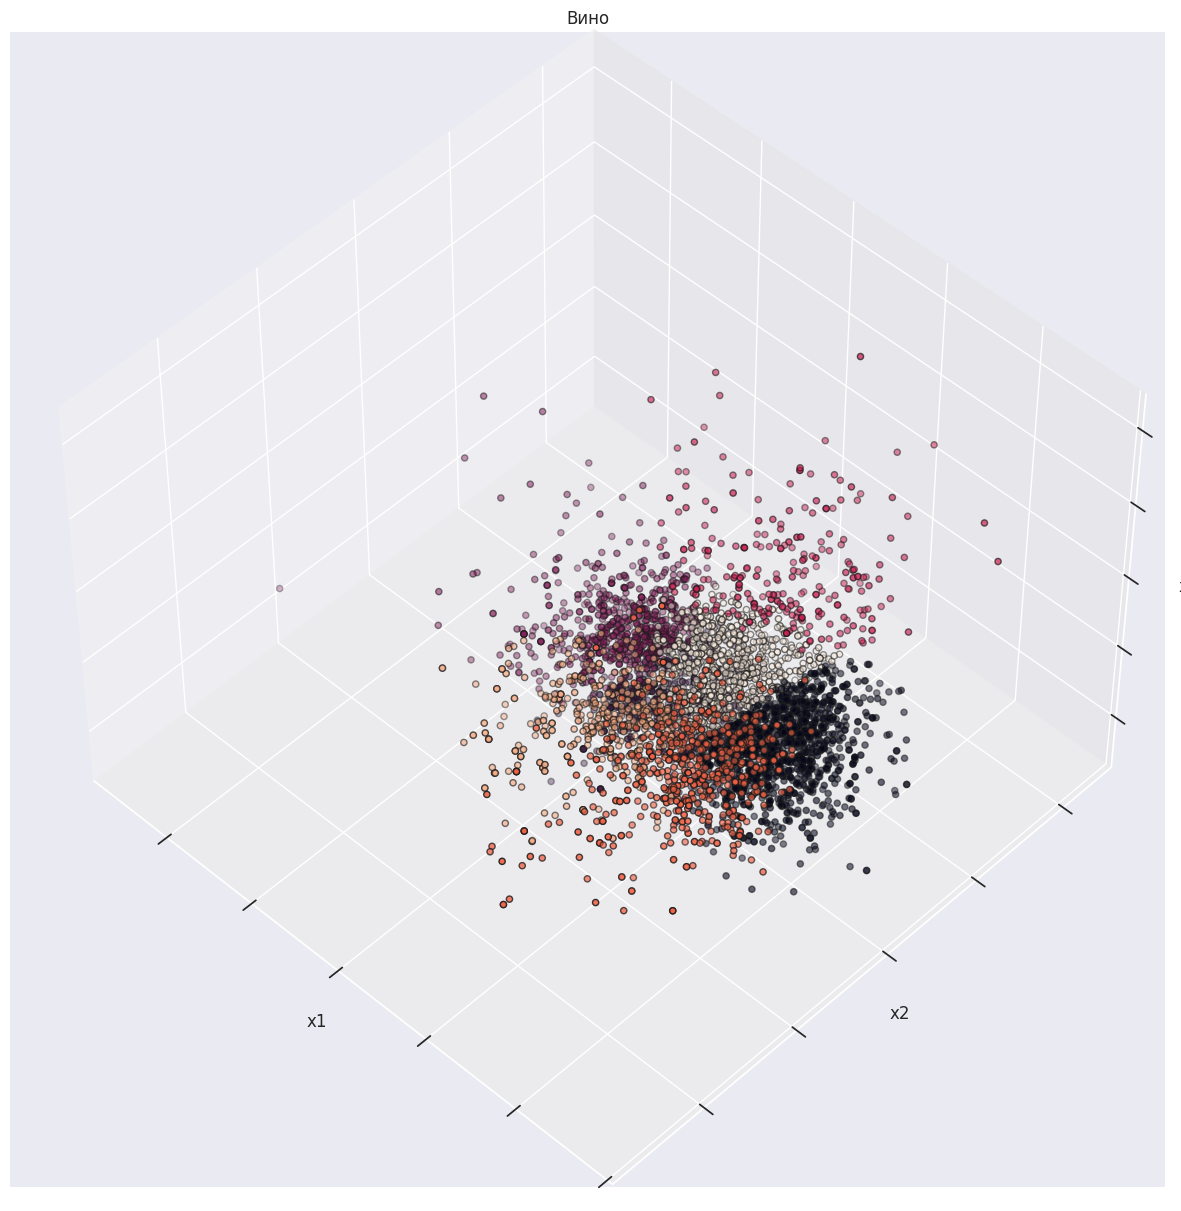

In [ ]:
est = KMeans(n_clusters=7, max_iter=10, n_init=10) # Из прошлой работы изветсно, что семь кластеров работают лучше всего
est.fit(db_pcaed)
db_pcaed = db_pcaed.transpose()

# Визуализация датасета

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db_pcaed[0], db_pcaed[1], db_pcaed[2],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("x1")
ax.set_ylabel ("x2")
ax.set_zlabel ("x3")
ax.set_title ("Вино")

plt.show()

# Кластеры выделяются нагляднее, чем без понижения размерности.

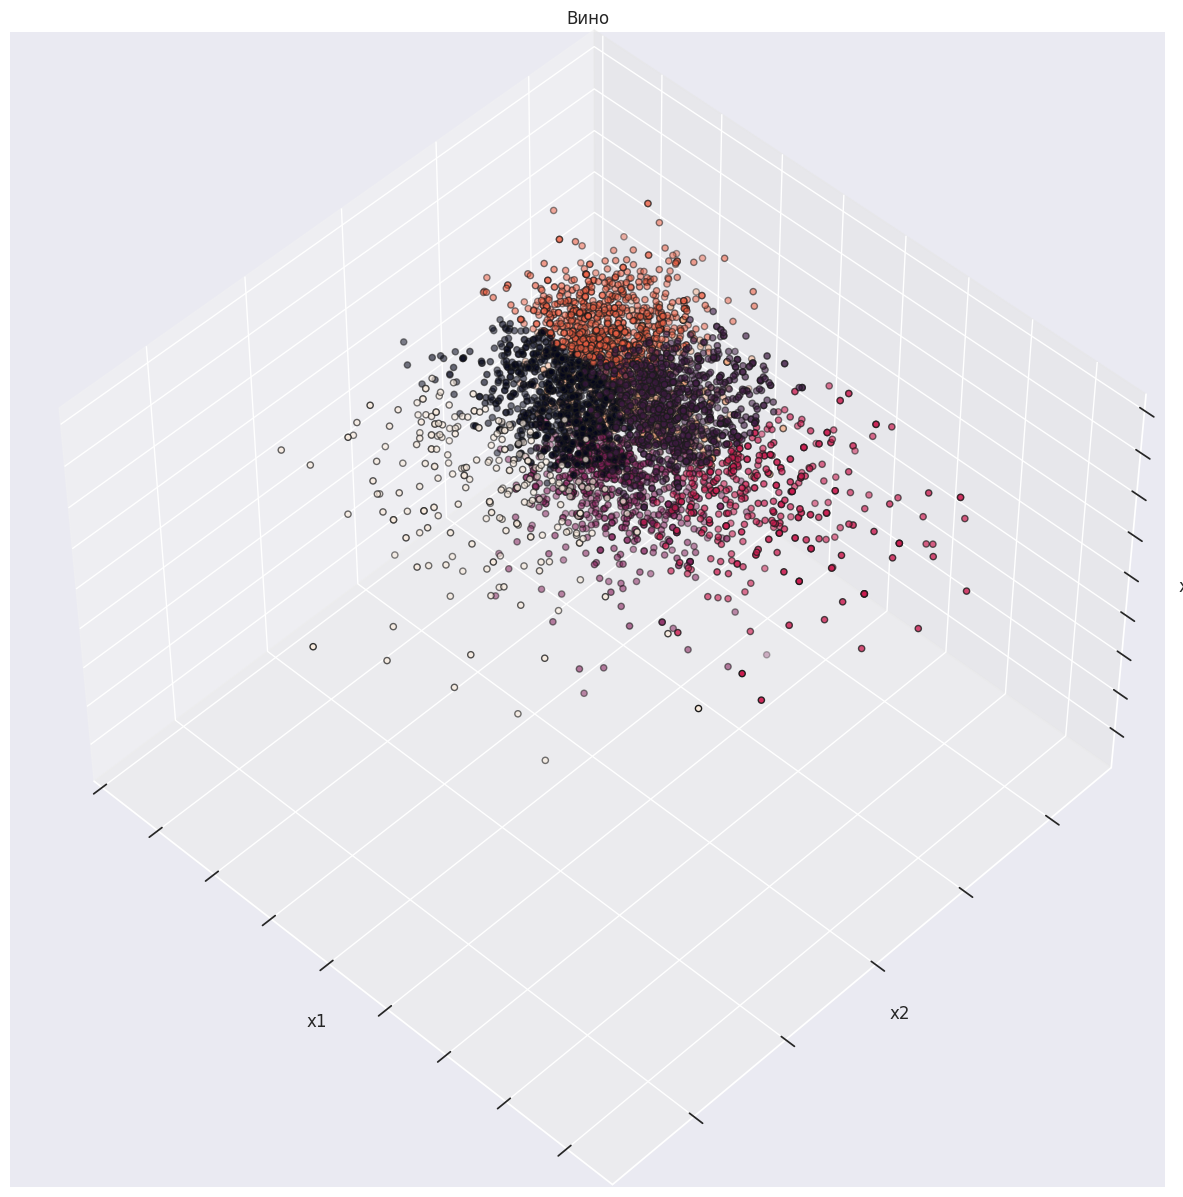

In [ ]:
from sklearn.decomposition import FastICA

# Понижение размерности методом независимого анализ компонентов (Independent Component Analysis, ICA)
fast_ica = FastICA(n_components=3)
db_icaed = fast_ica.fit_transform(db)

est = KMeans(n_clusters=7, max_iter=10, n_init=10) # Из прошлой работы изветсно, что семь кластеров работают лучше всего
est.fit(db_icaed)
db_icaed = db_icaed.transpose()

# Визуализация датасета

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db_icaed[0], db_icaed[1], db_icaed[2],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("x1")
ax.set_ylabel ("x2")
ax.set_zlabel ("x3")
ax.set_title ("Вино")

plt.show()
# Кластеры снова выделяются нагляднее, чем без понижения размерности.

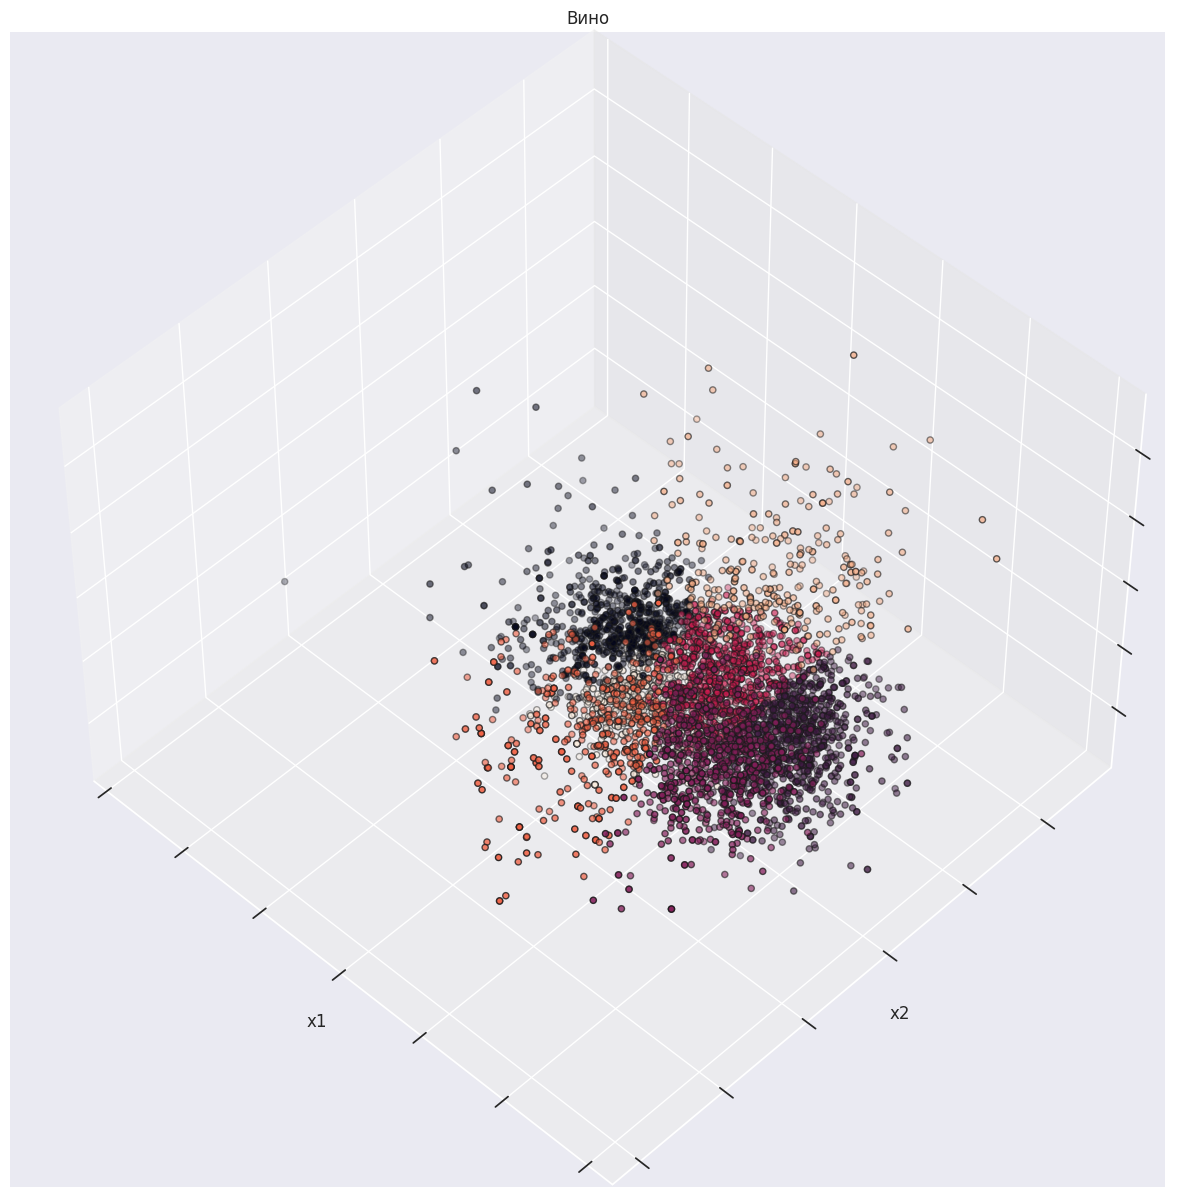

In [ ]:
from sklearn.decomposition import KernelPCA

# Понижение размерности методом главных компонентов (Principal Component Analysis, PCA), но с трюком ядра
rbf_pca = KernelPCA(n_components=3, kernel='rbf', gamma=0.04)  # Ядро RBA
db_new = rbf_pca.fit_transform(db)

est = KMeans(n_clusters=7, max_iter=10, n_init=10)
est.fit(db_new)
db_new = db_new.transpose()

# Визуализация датасета

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db_new[0], db_new[1], db_new[2],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("x1")
ax.set_ylabel ("x2")
ax.set_zlabel ("x3")
ax.set_title ("Вино")

plt.show()
# Кластеры снова выделяются нагляднее, чем без понижения размерности, а без трюка ядра было лучше.

In [4]:
from sklearn.manifold import TSNE

# Понижение размерности методом t-SNE
tsne = TSNE(n_components=3)
db_new = tsne.fit_transform(db)

est = KMeans(n_clusters=7, max_iter=10, n_init=10)
est.fit(db_new)
db_new = db_new.transpose()

# Визуализация датасета

fig = plt.figure (figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection="3d", elev=48, azim=134)

ax.scatter (db_new[0], db_new[1], db_new[2],
            c=est.labels_.astype(float), edgecolor="k")

ax.xaxis.set_ticklabels ([])
ax.yaxis.set_ticklabels ([])
ax.zaxis.set_ticklabels ([])
ax.set_xlabel ("x1")
ax.set_ylabel ("x2")
ax.set_zlabel ("x3")
ax.set_title ("Вино")

plt.show()
# Кластеры стали разреженными, один кластер обособился от остальных..

NameError: name 'KMeans' is not defined

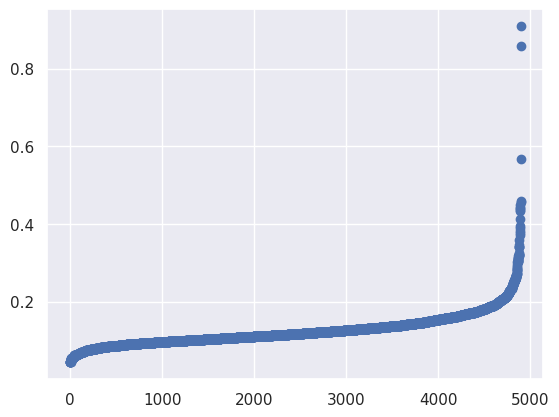

In [ ]:
# Внезапно, кластеризация методом dbscan

# Определение оптимального параметра эпсилон для метода dbscan
from sklearn.neighbors import NearestNeighbors
min_samples = 20
knn = NearestNeighbors(n_neighbors = min_samples, metric = 'l2')
knn.fit(db)
dists, inds = knn.kneighbors(db)
dists_ar = dists[:, 1:min_samples].mean(axis=1)
dists_ar.sort()
plt.scatter(x = range(len(dists_ar)), y=dists_ar)
plt.show()

# Выбирается eps по значению на оси ординат в точке перегиба графика, то есть порядка 0,22

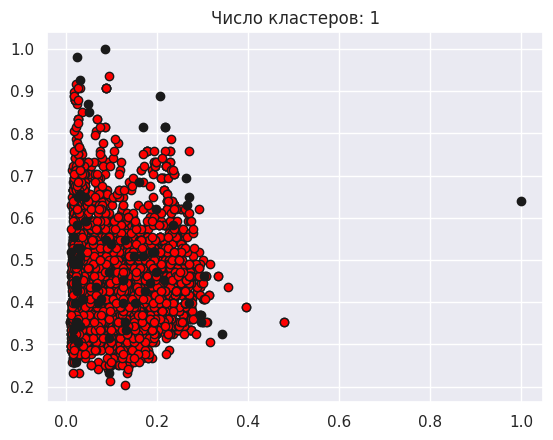

In [6]:
# пробуем dbscan на данных с пониженной методом t-sne размерностью.

from sklearn.cluster import DBSCAN

mins = db_new.shape[1]
dbscan = DBSCAN(eps=0.22, min_samples=15).fit(db)
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

labels = dbscan.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
unique_labels = set(labels)
colors = ["red", "green", "blue", "yellow", "magenta"]

for k, col in zip(unique_labels, colors):
	if k == -1:
		col = 'k'

	class_member_mask = (labels == k)

	xy = db[class_member_mask & core_samples_mask]
	plt.plot(xy["residual sugar"], xy["sulphates"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

	xy = db[class_member_mask & ~core_samples_mask]
	plt.plot(xy["residual sugar"], xy["sulphates"], 'o', markerfacecolor=col,
			markeredgecolor='k',
			markersize=6)

plt.title('Число кластеров: %d' % n_clusters_)
plt.show()

dbcsan плохо работает на этомдатасете, тут расстояния между семплами примерно одинаковы по всему пространству признаков.

In [7]:
n_noise = list(dbscan.labels_).count(-1)
print("Число выбросов по мнению DBScan: %d" % n_noise)

Число выбросов по мнению DBScan: 71
